In [1]:
# All the imports we need
import numpy as np
import gtsam
from gtsam.utils.plot import plot_pose3
from matplotlib import pyplot as plt
from gtsam.symbol_shorthand import B, V, X
from gtbook.display import show
from mpl_toolkits.mplot3d import Axes3D
# import matplotlib.pyplot as plt
%matplotlib inline

## Try example trajectories
Generate trajectories and plot them

In [2]:
T = 12  # The timespan of our trajectory.
dt = 1e-2  # 100 Hz frequency
velocity = np.array([2, 0, 0])  # The velocity we wish to move at.

scenarios = {
    "zero_twist": (np.zeros(3), np.zeros(3)),  # Zero motion, stationary trajectory.
    "forward_motion": (np.zeros(3), velocity),  # Move forward in the x axis at 2 m/s.
    "loop": (np.array([0, -np.radians(30), 0]), velocity),  # A loop-de-loop trajectory.
    "sick": (np.array([np.radians(30), -np.radians(30), 0]), velocity)  # A spiral trajectory, "sick" in surfer slang.
}

def plot_scenario(scenario,
                  T,
                  dt,
                  title="IMU trajectory scenario",
                  fignum=0,
                  maxDim=5):
    for t in np.arange(0, T, dt):
        # print(f"t={t:.2f}s")
        actualPose = scenario.pose(t)
        plot_pose3(fignum, actualPose, axis_length=0.3)

        translation = actualPose.translation()
        maxDim = max([max(np.abs(translation)), maxDim])
        ax = plt.gca()
        ax.set_xlim3d(-maxDim, maxDim)
        ax.set_ylim3d(-maxDim, maxDim)
        ax.set_zlim3d(-maxDim, maxDim)
        ax.set_title(title)
    # print("Plot")
    plt.show()
# print test
# for name, (angular_velocity, linear_velocity) in scenarios.items():
#     print(f"Scenario: {name}")
#     print(f"  Angular Velocity (rad/s): {angular_velocity}")
#     print(f"  Linear Velocity (m/s): {linear_velocity}\n")

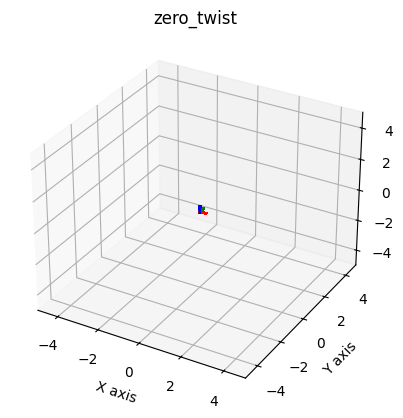

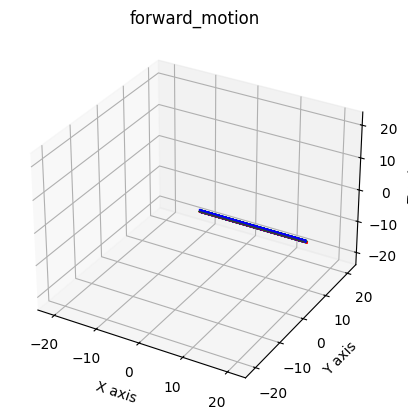

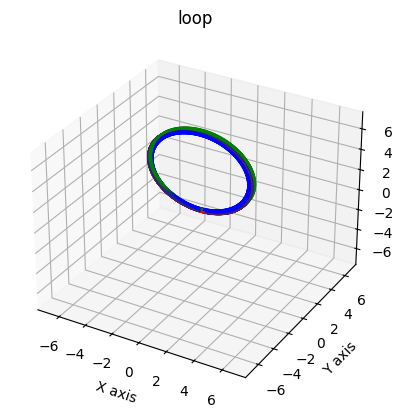

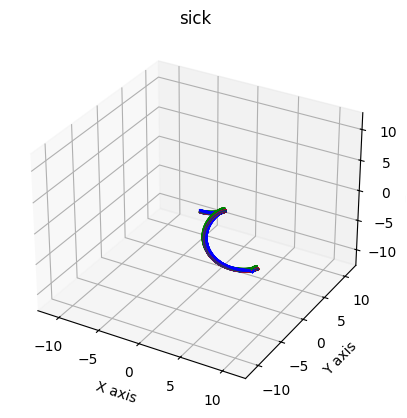

In [3]:
for idx, scenario_name in enumerate(scenarios.keys()):
    scenario = gtsam.ConstantTwistScenario(*scenarios[scenario_name])
    plot_scenario(scenario, T, dt, fignum=idx + 1, title=scenario_name)

Let's start with forward motion, the easiest 

In [4]:
scenario = gtsam.ConstantTwistScenario(*scenarios["forward_motion"])

# Let's visualize it for our understanding
# plot_scenario(scenario, T, dt, title="Forward Motion", fignum=5)

Add imu bias

In [5]:
accBias = np.array([-0.3, 0.1, 0.2])
gyroBias = np.array([0.1, 0.3, -0.1])
actualBias = gtsam.imuBias.ConstantBias(accBias, gyroBias)

## Define IMU parameters

In [6]:
pim_params = gtsam.PreintegrationParams.MakeSharedU(9.81)

# Some arbitrary noise sigmas
gyro_sigma = 1e-3
accel_sigma = 1e-3
I_3x3 = np.eye(3)
pim_params.setGyroscopeCovariance(gyro_sigma**2 * I_3x3)
pim_params.setAccelerometerCovariance(accel_sigma**2 * I_3x3)
pim_params.setIntegrationCovariance(1e-7**2 * I_3x3)

# Define the PreintegratedImuMeasurements object here.
pim = gtsam.PreintegratedImuMeasurements(pim_params, actualBias)

runner = gtsam.ScenarioRunner(scenario, pim_params, dt, actualBias)
# plot_scenario(scenario, T, dt, fignum=6)

Main loop for creating imu factor

In [7]:
def main_loop(runner, scenario, graph, initial, T):
    # The factor index for the estimation rate
    i = 0

    for k, t in enumerate(np.arange(0, T, dt)):
        # get measurements and add them to PIM
        measuredOmega = runner.measuredAngularVelocity(t)
        measuredAcc = runner.measuredSpecificForce(t)

        ### This is where all the magic happens!
        pim.integrateMeasurement(measuredAcc, measuredOmega, dt)

        if (k + 1) % int(1 / dt) == 0:
            # Create IMU factor every second.
            factor = gtsam.ImuFactor(X(i), V(i), X(i + 1), V(i + 1), B(0), pim)
            graph.push_back(factor)

            # We have created the binary constraint, so we clear out the preintegration values.
            pim.resetIntegration()

            # Get the true state which we will corrupt with some additive noise terms defined below
            actual_state_i = scenario.navState(t + dt)

            # These are additive noise terms.
            rotationNoise = gtsam.Rot3.Expmap(np.random.randn(3) * 0.1)
            translationNoise = gtsam.Point3(*np.random.randn(3) * 1)
            poseNoise = gtsam.Pose3(rotationNoise, translationNoise)

            noisy_state_i = gtsam.NavState(
                actual_state_i.pose().compose(poseNoise),
                actual_state_i.velocity() + np.random.randn(3) * 0.1)

            initial.insert(X(i + 1), noisy_state_i.pose())
            initial.insert(V(i + 1), noisy_state_i.velocity())
            i += 1

    return graph, initial

## Factor Graph

Add priior pose and velocity

In [8]:
graph = gtsam.NonlinearFactorGraph()
initial = gtsam.Values()

def add_priors(scenario, graph, initial):
    # Noise models for
    priorNoise = gtsam.noiseModel.Isotropic.Sigma(6, 0.1)
    velNoise = gtsam.noiseModel.Isotropic.Sigma(3, 0.1)

    initial_state = scenario.navState(0)
    graph.push_back(
        gtsam.PriorFactorPose3(X(0), initial_state.pose(), priorNoise))
    graph.push_back(
        gtsam.PriorFactorVector(V(0), initial_state.velocity(), velNoise))

    initial.insert(B(0), actualBias)
    initial.insert(X(0), initial_state.pose())
    initial.insert(V(0), initial_state.velocity())

    return graph, initial


graph, initial = add_priors(scenario, graph, initial)

Run the main loop

In [9]:
graph, initial = main_loop(runner, scenario, graph, initial, T)

Do some plots!

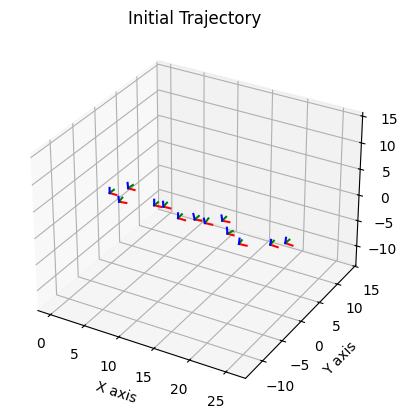

In [10]:
def plot_trajectory(values: gtsam.Values,
                    title: str = "Estimated Trajectory",
                    fignum: int = 1,
                    show: bool = False):
    i = 0
    while values.exists(X(i)):
        pose_i = values.atPose3(X(i))
        plot_pose3(fignum, pose_i, 1)
        i += 1
    plt.title(title)

    gtsam.utils.plot.set_axes_equal(fignum)

    plt.ioff()

    if show:
        plt.show()


plot_trajectory(initial, title="Initial Trajectory", fignum=7, show=True)

As can be observed in the figure, the trjectory from the main loop doesn't follow the initial trajectory

## Optimization

In [11]:
lm_params = gtsam.LevenbergMarquardtParams()
lm_params.setVerbosityLM("SUMMARY")
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial, lm_params)
result = optimizer.optimize()

Initial error: 1.6781e+08, values: 27
iter      cost      cost_change    lambda  success iter_time
   0  2.78383e+06      1.7e+08      1e-05      1          0
   1      5.8e+02      2.8e+06      1e-06      1          0
   2      5.1e-06      5.8e+02      1e-07      1          0
   3      4.7e-22      5.1e-06      1e-08      1          0


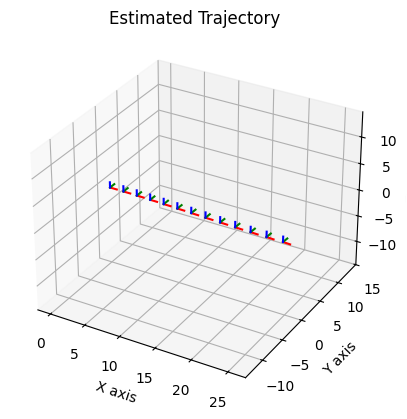

In [12]:
plot_trajectory(result, fignum=8, show=True)

After optimizing, the trajectpry is corrected.